In [93]:
import gzip
import os
import pathlib
import tempfile
from concurrent.futures import ThreadPoolExecutor, as_completed
from io import StringIO, BytesIO

import earthaccess
import geopandas as gpd
import holoviews as hv
import hvplot.pandas
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shapely
import requests
import rioxarray as rxr
import xarray as xr
from tqdm.notebook import tqdm
import utilities as util
import glob

data_dir = pathlib.Path().cwd().parent / 'data'
swot_path = data_dir / 'usgs_swot_data' / 'swot_timeseries_for_usgs_nodes.csv'
mrms_path_flag = data_dir / 'usgs_mrms_data' 
usgs_path = data_dir / 'usgs_stage_data'


['/Users/masa6503/repos/swot-precip-validation/data/usgs_mrms_data/usgs_MRMS_RadarAccumulationQualityIndex_01H_00.00.csv',
 '/Users/masa6503/repos/swot-precip-validation/data/usgs_mrms_data/usgs_MRMS_PrecipRate_00.00.csv',
 '/Users/masa6503/repos/swot-precip-validation/data/usgs_mrms_data/usgs_MRMS_RadarQualityIndex_00.00.csv',
 '/Users/masa6503/repos/swot-precip-validation/data/usgs_mrms_data/usgs_MRMS_PrecipFlag_00.00.csv']

In [97]:
glob.glob(str(usgs_path / '*.parquet'))

['/Users/masa6503/repos/swot-precip-validation/data/usgs_stage_data/usgs_stage_data_150_200.parquet',
 '/Users/masa6503/repos/swot-precip-validation/data/usgs_stage_data/usgs_stage_data_800_850.parquet',
 '/Users/masa6503/repos/swot-precip-validation/data/usgs_stage_data/usgs_stage_data_200_250.parquet',
 '/Users/masa6503/repos/swot-precip-validation/data/usgs_stage_data/usgs_stage_data_700_750.parquet',
 '/Users/masa6503/repos/swot-precip-validation/data/usgs_stage_data/usgs_stage_data_0_50.parquet',
 '/Users/masa6503/repos/swot-precip-validation/data/usgs_stage_data/usgs_stage_data_500_550.parquet',
 '/Users/masa6503/repos/swot-precip-validation/data/usgs_stage_data/usgs_stage_data_250_300.parquet',
 '/Users/masa6503/repos/swot-precip-validation/data/usgs_stage_data/usgs_stage_data_850_871.parquet',
 '/Users/masa6503/repos/swot-precip-validation/data/usgs_stage_data/usgs_stage_data_450_500.parquet',
 '/Users/masa6503/repos/swot-precip-validation/data/usgs_stage_data/usgs_stage_data_5

In [159]:
# Combine all data
merged_data_sets = []
for usgs_file in glob.glob(str(usgs_path / '*.parquet')):
    print(usgs_file)
    #Read in SWOT, MRMS, and 
    swot_ts_df = (
        pd.read_csv(
            swot_path, 
            na_values=['no_data'],
            index_col=['node_id', 'time_str'],
            parse_dates=True)
        .rename_axis(index={"time_str": "time"})
    )
    swot_ts_df = swot_ts_df[swot_ts_df.index.get_level_values("time").notna()]
    usgs_obs = pd.read_parquet(usgs_file)
    # mrms_flag_df = pd.read_csv(mrms_path_flag, index_col=['node_id', 'mrms_time'], parse_dates=True)
    stations = util.retrieve_stations()
    stations_to_merge=stations[['usgs_site_no', 'node_id']].drop_duplicates()
    stations_to_merge['usgs_site_no'] = 'USGS-' + stations_to_merge['usgs_site_no'].astype(str)
    swot_merge = swot_ts_df.copy()
    usgs_merge = usgs_obs.copy()
    swot_merge.reset_index(inplace=True)
    swot_merge.rename(columns={"time":"nodetime"},inplace=True)
    swot_merge=swot_merge.sort_values("nodetime")

    usgs_merge.rename(columns={"time":"usgstime"}, inplace=True)
    usgs_merge = usgs_merge.sort_values("usgstime")
    usgs_merge = pd.merge(usgs_merge, stations_to_merge, left_on="monitoring_location_id", 
                        right_on="usgs_site_no", how="inner")

    combined = pd.merge_asof(swot_merge, usgs_merge, 
                            left_on="nodetime", 
                            right_on="usgstime",
                            direction="nearest",
                            by="node_id",
                            tolerance=pd.Timedelta("1 hour"))
    combined['usgs_height_m'] = combined['value']*0.3048
    combined=combined[combined['monitoring_location_id'].notna()]
    combined["time_utc"] = combined["nodetime"].dt.tz_convert("UTC")
    combined["mrms_time_hourly"] = combined["time_utc"].dt.floor("h")
    combined["mrms_time_2_min"] = combined["time_utc"].dt.floor("2min")
    # mrms_flag_df.reset_index(inplace=True)
    # combined_all = pd.merge(combined, mrms_flag_df, left_on=["node_id", "mrms_time_2_min"], right_on=["node_id", "mrms_time"], how="inner")

    combined.set_index("node_id", inplace=True)
    # combined['diff_usgs_swot'] = combined['wse'] - combined['usgs_height_m']
    combined = combined[np.abs(combined['wse'])<1000000]
    # combined['diff_usgs_swot_median'] = combined.groupby('node_id').agg({'diff_usgs_swot': 'median'}).reset_index().set_index('node_id')

    merged_data_sets.append(combined)

merged_all = pd.concat(merged_data_sets).reset_index()
merged_ref_copy = merged_all.copy()
for mrms_file in glob.glob(str(mrms_path_flag / '*.csv')):
    print(mrms_file)
    mrms_flag_df = pd.read_csv(mrms_file, index_col=['node_id', 'mrms_time'], parse_dates=True)
    mrms_flag_df.reset_index(inplace=True)
    if '01H' in mrms_file:
        merged_all = pd.merge(merged_all, mrms_flag_df, left_on=["node_id", "mrms_time_hourly"], right_on=["node_id", "mrms_time"], how="inner")
    else:
        merged_all = pd.merge(merged_all, mrms_flag_df, left_on=["node_id", "mrms_time_2_min"], right_on=["node_id", "mrms_time"], how="inner")
    merged_all.drop('mrms_time', axis=1, inplace=True)

merged_all.to_csv(data_dir / 'merged_usgs_swot_mrms_data.csv', index=False)

/Users/masa6503/repos/swot-precip-validation/data/usgs_stage_data/usgs_stage_data_150_200.parquet


/var/folders/h8/7yhvl39x7dn5889b60w34ty40000gs/T/ipykernel_40784/3883547727.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.read_csv(


/Users/masa6503/repos/swot-precip-validation/data/usgs_stage_data/usgs_stage_data_800_850.parquet


/var/folders/h8/7yhvl39x7dn5889b60w34ty40000gs/T/ipykernel_40784/3883547727.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.read_csv(


/Users/masa6503/repos/swot-precip-validation/data/usgs_stage_data/usgs_stage_data_200_250.parquet


...

/var/folders/h8/7yhvl39x7dn5889b60w34ty40000gs/T/ipykernel_40784/3883547727.py:56: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  mrms_flag_df = pd.read_csv(mrms_file, index_col=['node_id', 'mrms_time'], parse_dates=True)


/Users/masa6503/repos/swot-precip-validation/data/usgs_mrms_data/usgs_MRMS_RadarQualityIndex_00.00.csv


/var/folders/h8/7yhvl39x7dn5889b60w34ty40000gs/T/ipykernel_40784/3883547727.py:56: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  mrms_flag_df = pd.read_csv(mrms_file, index_col=['node_id', 'mrms_time'], parse_dates=True)


/Users/masa6503/repos/swot-precip-validation/data/usgs_mrms_data/usgs_MRMS_PrecipFlag_00.00.csv


/var/folders/h8/7yhvl39x7dn5889b60w34ty40000gs/T/ipykernel_40784/3883547727.py:56: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  mrms_flag_df = pd.read_csv(mrms_file, index_col=['node_id', 'mrms_time'], parse_dates=True)


In [219]:
merged_all = pd.read_csv(data_dir / 'merged_usgs_swot_mrms_data.csv')
datum_difference = merged_all.copy()

# Remove NA rows
# datum_difference = datum_difference[datum_difference.index.get_level_values("nodetime").notna()]

# Filter data
# datum_difference = swot_ts_df.copy()
# Not ice
datum_difference = datum_difference[datum_difference.ice_clim_f==0]
# Not bad xover
datum_difference = datum_difference[datum_difference.xovr_cal_q<2]
# Not bad xover
datum_difference = datum_difference[datum_difference.node_q<3]
# Not far or near swath
datum_difference = datum_difference[datum_difference.node_q_b.apply(util.filter_bits, args=[[13,14,19,23,24]])]

datum_difference.set_index("node_id", inplace=True)
datum_difference['diff_usgs_swot'] = datum_difference['wse'] - datum_difference['usgs_height_m']
# datum_difference = datum_difference[np.abs(combined['wse'])<1000000]
datum_difference['diff_usgs_swot_median'] = datum_difference.groupby('node_id').agg({'diff_usgs_swot': 'median'}).reset_index().set_index('node_id')
merged_all.set_index("node_id", inplace=True)

merged_all=merged_all.merge(datum_difference[['diff_usgs_swot_median']].drop_duplicates(), left_index=True, right_index=True, how='inner', suffixes=('', '_median')).reset_index()

/var/folders/h8/7yhvl39x7dn5889b60w34ty40000gs/T/ipykernel_40784/4006621754.py:1: DtypeWarning: Columns (55) have mixed types. Specify dtype option on import or set low_memory=False.
  merged_all = pd.read_csv(data_dir / 'merged_usgs_swot_mrms_data.csv')


In [220]:
merged_all.dropna(subset=['wse', 
                          'usgs_height_m', 
                          'nodetime',
                          'node_id', 
                          'usgs_height_m',
                          'RadarAccumulationQualityIndex_01H_00.00',
                          'PrecipRate_00.00',
                          'RadarQualityIndex_00.00',
                          'PrecipFlag_00.00'], inplace=True)
merged_all['usgs_height_plus_median_diff'] = merged_all['usgs_height_m'] + merged_all['diff_usgs_swot_median']
merged_all['swot_minus_usgs_height_plus_diff'] = merged_all['wse'] - merged_all['usgs_height_plus_median_diff']
merged_all['swot_minus_usgs_height_plus_diff_abs'] = np.abs(merged_all['wse'] - merged_all['usgs_height_plus_median_diff'])


In [230]:
merged_all.columns

Index(['node_id', 'nodetime', 'wse', 'width', 'area_total', 'node_q_b',
       'ice_clim_f', 'xovr_cal_q', 'p_dam_id', 'node_q', 'dark_frac',
       'n_good_pix', 'lat', 'lon', 'lat_u', 'lon_u', 'rdr_sig0', 'rdr_sig0_u',
       'rdr_pol', 'dry_trop_c', 'wet_trop_c', 'iono_c', 'xovr_cal_c', 'p_wse',
       'p_wse_var', 'p_width', 'p_wid_var', 'wse_units', 'width_units',
       'area_total_units', 'p_dam_id_units', 'dark_frac_units',
       'n_good_pix_units', 'lat_units', 'lon_units', 'lat_u_units',
       'lon_u_units', 'rdr_sig0_units', 'rdr_sig0_u_units', 'dry_trop_c_units',
       'wet_trop_c_units', 'iono_c_units', 'xovr_cal_c_units', 'p_wse_units',
       'p_wse_var_units', 'p_width_units', 'p_wid_var_units', 'time_series_id',
       'monitoring_location_id', 'parameter_code', 'statistic_id', 'usgstime',
       'value', 'unit_of_measure', 'approval_status', 'qualifier',
       'last_modified', 'continuous_id', 'usgs_site_no', 'usgs_height_m',
       'time_utc', 'mrms_time_hourly',

In [453]:
wse_error = merged_all.copy()[['node_id',
                               'monitoring_location_id',
                               'nodetime',
                               'wse', 
                               'usgs_height_m',
                               'diff_usgs_swot_median',
                               'usgs_height_plus_median_diff', 
                               'swot_minus_usgs_height_plus_diff',
                               'swot_minus_usgs_height_plus_diff_abs',
                               'RadarAccumulationQualityIndex_01H_00.00',
                               'PrecipRate_00.00',
                               'RadarQualityIndex_00.00',
                               'PrecipFlag_00.00',
                               'rdr_sig0',
                               'dark_frac',
                               'node_q_b',
                               'node_q',
                               'xovr_cal_q',
                               'ice_clim_f'
                               ]]

wse_error = wse_error[wse_error['RadarQualityIndex_00.00']>0.6]

flag_mapping = {
    -3: 'No Coverage',
    0: 'No Precip',
    1: 'Warm Stratiform',
    3: 'Snow',
    6: 'Convective Rain',
    7: 'Rain Mixed Hail',
    10: 'Cold Stratiform',
    91: 'Tropical/stratiform',
    96: 'Tropical/convective'
}

wse_error = wse_error.assign(precip_type_labeled = lambda df: df['PrecipFlag_00.00'].map(flag_mapping)).fillna("Unknown")
wse_error['precip_bin_mm_hr'] = pd.cut(wse_error['PrecipRate_00.00'], [-1,0.1,1,2,3,4,5,6,7,8,9,10,11,12,13], labels = ['0','0-1','1-2','2-3','3-4','4-5','5-6','6-7','7-8','8-9','9-10', '10-11','11-12','12-13'])


In [454]:
# Not ice
wse_error_filtered = wse_error[wse_error.ice_clim_f==0]
# Not bad xover
wse_error_filtered = wse_error_filtered[wse_error_filtered.xovr_cal_q<2]
# Not bad xover
wse_error_filtered = wse_error_filtered[wse_error_filtered.node_q<3]
# Not far or near swath
wse_error_filtered = wse_error_filtered[wse_error_filtered.node_q_b.apply(util.filter_bits, args=[[13,14,19,23,24]])]
# swot_filter_df = swot_filter_df[swot_filter_df.node_q_b.apply(filter_bits)]

In [455]:
wse_median_error=wse_error_filtered.groupby('node_id').agg({'swot_minus_usgs_height_plus_diff': 'mean'}).reset_index().set_index('node_id')
# datum_difference['diff_usgs_swot_median'] = datum_difference.groupby('node_id').agg({'diff_usgs_swot': 'median'}).reset_index().set_index('node_id')

/var/folders/h8/7yhvl39x7dn5889b60w34ty40000gs/T/ipykernel_40784/1214790374.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


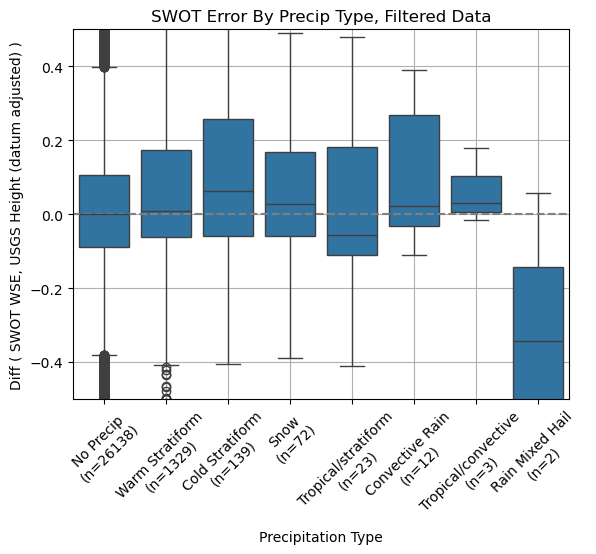

In [456]:
counts = wse_error_filtered.groupby('precip_type_labeled').size()
# box_order = wse_error_filtered['precip_type_labeled'].unique()
box_order=counts.sort_values(ascending=False).index

ax = sns.boxplot(data=wse_error_filtered, x='precip_type_labeled', y='swot_minus_usgs_height_plus_diff', 
    order = counts.sort_values(ascending=False).index
    )
ax.set_xticklabels(
    [f"{cat}\n(n={counts[cat]})" for cat in box_order],
    rotation=45
)
ax.set_xlabel("Precipitation Type")

# Add a dashed horizontal line at y=0
plt.axhline(0, color='gray', linestyle='--')
plt.title(f"SWOT Error By Precip Type, Filtered Data")
plt.ylabel("Diff ( SWOT WSE, USGS Height (datum adjusted) )")
plt.ylim(-0.5,0.5)
plt.grid()
plt.show()

No Precip
Warm Stratiform
Cold Stratiform


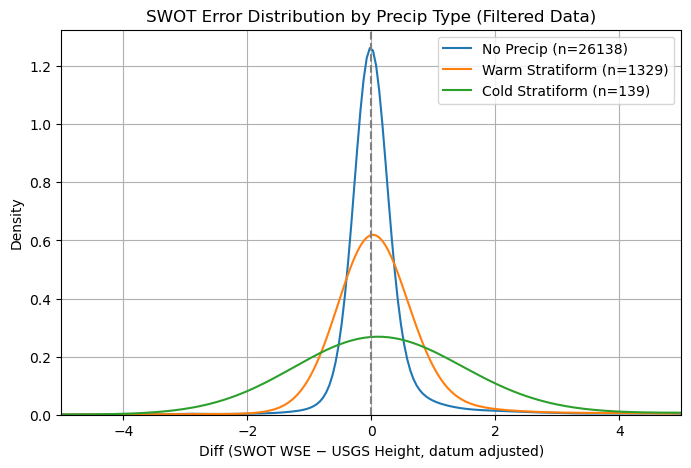

In [459]:
top_cats = wse_error_filtered[wse_error_filtered['precip_type_labeled'].isin(['No Precip', 'Warm Stratiform', 'Cold Stratiform'])]
counts = top_cats.groupby('precip_type_labeled').size()
box_order = counts.sort_values(ascending=False).index

plt.figure(figsize=(8,5))

for cat in box_order:
    subset = top_cats[top_cats['precip_type_labeled'] == cat]
    print(cat)

    sns.kdeplot(
        subset['swot_minus_usgs_height_plus_diff'],
        label=f"{cat} (n={counts[cat]})",
        fill=False,
        clip=(-5, 5)
    )

# reference line
plt.axvline(0, color='gray', linestyle='--')

plt.title("SWOT Error Distribution by Precip Type (Filtered Data)")
plt.xlabel("Diff (SWOT WSE − USGS Height, datum adjusted)")
plt.ylabel("Density")
plt.xlim(-5, 5)

plt.grid()
plt.legend()
plt.show()

/var/folders/h8/7yhvl39x7dn5889b60w34ty40000gs/T/ipykernel_40784/196552362.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


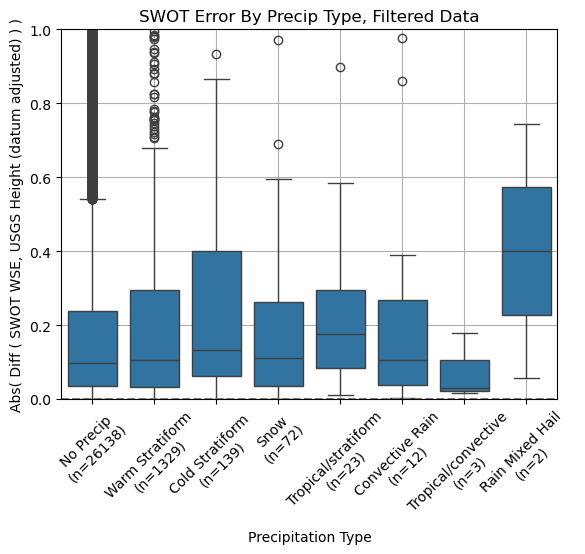

In [325]:
counts = wse_error_filtered.groupby('precip_type_labeled').size()
# box_order = wse_error_filtered['precip_type_labeled'].unique()
box_order=counts.sort_values(ascending=False).index

ax = sns.boxplot(data=wse_error_filtered, x='precip_type_labeled', y='swot_minus_usgs_height_plus_diff_abs', 
    order = counts.sort_values(ascending=False).index
    )
ax.set_xticklabels(
    [f"{cat}\n(n={counts[cat]})" for cat in box_order],
    rotation=45
)
ax.set_xlabel("Precipitation Type")

# Add a dashed horizontal line at y=0
plt.axhline(0, color='gray', linestyle='--')
plt.title(f"SWOT Error By Precip Type, Filtered Data")
plt.ylabel("Abs( Diff ( SWOT WSE, USGS Height (datum adjusted) ) )")
plt.ylim(0,1)
plt.grid()
plt.show()

/var/folders/h8/7yhvl39x7dn5889b60w34ty40000gs/T/ipykernel_40784/497755054.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = warm_stratiform.groupby('precip_bin_mm_hr').size()
/var/folders/h8/7yhvl39x7dn5889b60w34ty40000gs/T/ipykernel_40784/497755054.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


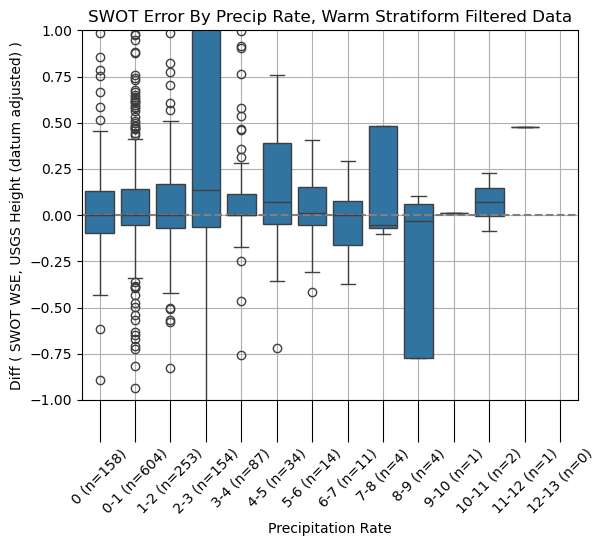

In [326]:
warm_stratiform = wse_error_filtered[wse_error_filtered['precip_type_labeled']=='Warm Stratiform']


counts = warm_stratiform.groupby('precip_bin_mm_hr').size()
# box_order = warm_stratiform['precip_bin_mm_hr'].unique()
# box_order=counts.sort_values(ascending=False).index

ax = sns.boxplot(data=warm_stratiform, x='precip_bin_mm_hr', y='swot_minus_usgs_height_plus_diff'
    )
ax.set_xticklabels(
    [f"{cat} (n={counts[cat]})" for cat in counts.index],
    rotation=45
)
ax.set_xlabel("Precipitation Rate")
ax.tick_params(axis='x', length=30)
# Add a dashed horizontal line at y=0
plt.axhline(0, color='gray', linestyle='--')
plt.title(f"SWOT Error By Precip Rate, Warm Stratiform Filtered Data")
plt.ylabel("Diff ( SWOT WSE, USGS Height (datum adjusted) )")
plt.ylim(-1,1)
# plt.xticks(rotation=45)
plt.grid()
plt.show()

In [333]:
wse_error_filtered['monitoring_location_id'].unique()
stations_used = stations[("USGS-"+stations['usgs_site_no']).isin(wse_error_filtered['monitoring_location_id'].unique())]

In [370]:
from datetime import datetime, timedelta, timezone
import dataretrieval.waterdata as waterdata
def retrieve_station_geometry(usgs_id_list):
    # tomorrow = datetime.now(tz=timezone.utc) + timedelta(days=2)
    # Format as ISO 8601 UTC midnight
    # fields = ['monitoring_location_id']
    # if geometry:
    #         fields.append('geometry')
    all_stations = []
    for i in range(0, len(usgs_id_list), 50):
        end_index = min(i + 50, len(usgs_id_list))
        # print(i, end_index)

        active_ids = waterdata.get_monitoring_locations(
            monitoring_location_id=list(usgs_id_list[i:end_index]), 
        )[0]
        all_stations.append(active_ids)
       
    return (all_stations)

In [371]:
os.environ['API_USGS_PAT'] = 'lpK2Fw6n4cZpD28LUAxmvwhluFrhyyohhlTPbV7m'
station_geometry = retrieve_station_geometry(("USGS-"+stations['usgs_site_no']))
station_geometry = pd.concat(station_geometry)

In [439]:
np.sqrt((wse_error_filtered[wse_error_filtered['precip_type_labeled']=="No Precip"]['swot_minus_usgs_height_plus_diff']**2).mean())

np.float64(1.7842191949604544)

In [386]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
def calculate_metrics(group):
    # mae = mean_absolute_error(group['wse'], group['usgs_height_plus_median_diff'])
    rmse = root_mean_squared_error(group['wse'], group['usgs_height_plus_median_diff'])
    r2 = r2_score(group['wse'], group['usgs_height_plus_median_diff'])
    return pd.Series({'RMSE': rmse, 'R2': r2})

In [389]:
experimental = wse_error_filtered.groupby('monitoring_location_id').apply(calculate_metrics).reset_index()

/opt/anaconda3/envs/swot/lib/python3.11/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/anaconda3/envs/swot/lib/python3.11/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/anaconda3/envs/swot/lib/python3.11/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/anaconda3/envs/swot/lib/python3.11/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/anaconda3/envs/swot/lib/python3.11/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is 

In [430]:
rmse = wse_error_filtered.groupby('precip_type_labeled').apply(calculate_metrics).reset_index()

/var/folders/h8/7yhvl39x7dn5889b60w34ty40000gs/T/ipykernel_40784/1448433560.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse = wse_error_filtered.groupby('precip_type_labeled').apply(calculate_metrics).reset_index()


In [431]:
rmse

,precip_type_labeled,RMSE,R2
0,Cold Stratiform,3.587712,0.999907
1,Convective Rain,0.403712,0.999994
2,No Precip,1.784219,0.999970
3,Rain Mixed Hail,0.528152,0.999937
4,Snow,1.387716,0.999979
5,Tropical/convective,0.105453,0.999979
6,Tropical/stratiform,0.396989,0.999989
7,Warm Stratiform,2.286098,0.999934


In [429]:
wse_error_filtered

,node_id,monitoring_location_id,nodetime,wse,usgs_height_m,diff_usgs_swot_median,usgs_height_plus_median_diff,swot_minus_usgs_height_plus_diff,swot_minus_usgs_height_plus_diff_abs,RadarAccumulationQualityIndex_01H_00.00,...,RadarQualityIndex_00.00,PrecipFlag_00.00,rdr_sig0,dark_frac,node_q_b,node_q,xovr_cal_q,ice_clim_f,precip_type_labeled,precip_bin_mm_hr
0,73260400380171,USGS-02347500,2023-07-26 22:09:58+00:00,102.17142,0.594360,101.676478,102.270838,-0.099418,0.099418,0.98,...,1.0,1.0,8.502,0.064226,1,1,0,0,Warm Stratiform,1-2
1,73258000050221,USGS-02323500,2023-07-26 22:10:55+00:00,4.69326,1.237488,-0.341696,0.895792,3.797468,3.797468,0.70,...,0.7,0.0,79.175,0.062471,22,1,0,0,No Precip,0
2,73270600040241,USGS-02376033,2023-07-27 11:20:16+00:00,0.31747,0.688848,-0.268408,0.420440,-0.102970,0.102970,0.95,...,1.0,0.0,14.102,0.058786,6,1,0,0,No Precip,0
3,73270600080571,USGS-02375500,2023-07-27 11:20:21+00:00,10.03789,1.871472,8.393638,10.265110,-0.227220,0.227220,0.93,...,0.9,0.0,15.533,0.000000,0,0,0,0,No Precip,0
6,73287000180061,USGS-02407000,2023-07-27 11:21:03+00:00,117.43804,4.169664,116.111314,120.280978,-2.842938,2.842938,1.00,...,1.0,0.0,19.103,0.250246,6,1,0,0,No Precip,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65529,73218000100621,USGS-02105500,2026-01-27 23:11:50+00:00,7.61385,0.563880,7.277434,7.841314,-0.227464,0.227464,0.73,...,0.7,0.0,1.199,0.750207,4,1,0,0,No Precip,0
65530,73220700050471,USGS-02131000,2026-01-27 23:11:59+00:00,9.80284,2.874264,6.967320,9.841584,-0.038744,0.038744,0.73,...,0.7,0.0,4.693,0.204067,6,1,0,0,No Precip,0
65531,73240200410171,USGS-02169000,2026-01-28 12:23:42+00:00,45.45631,0.762000,44.610332,45.372332,0.083978,0.083978,1.00,...,1.0,0.0,34.240,0.154537,6,1,0,0,No Precip,0
65537,73240200410171,USGS-02169000,2026-01-28 23:12:36+00:00,45.19381,0.765048,44.610332,45.375380,-0.181570,0.181570,1.00,...,1.0,0.0,11.433,0.137836,4,1,0,0,No Precip,0


/opt/anaconda3/envs/swot/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/anaconda3/envs/swot/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


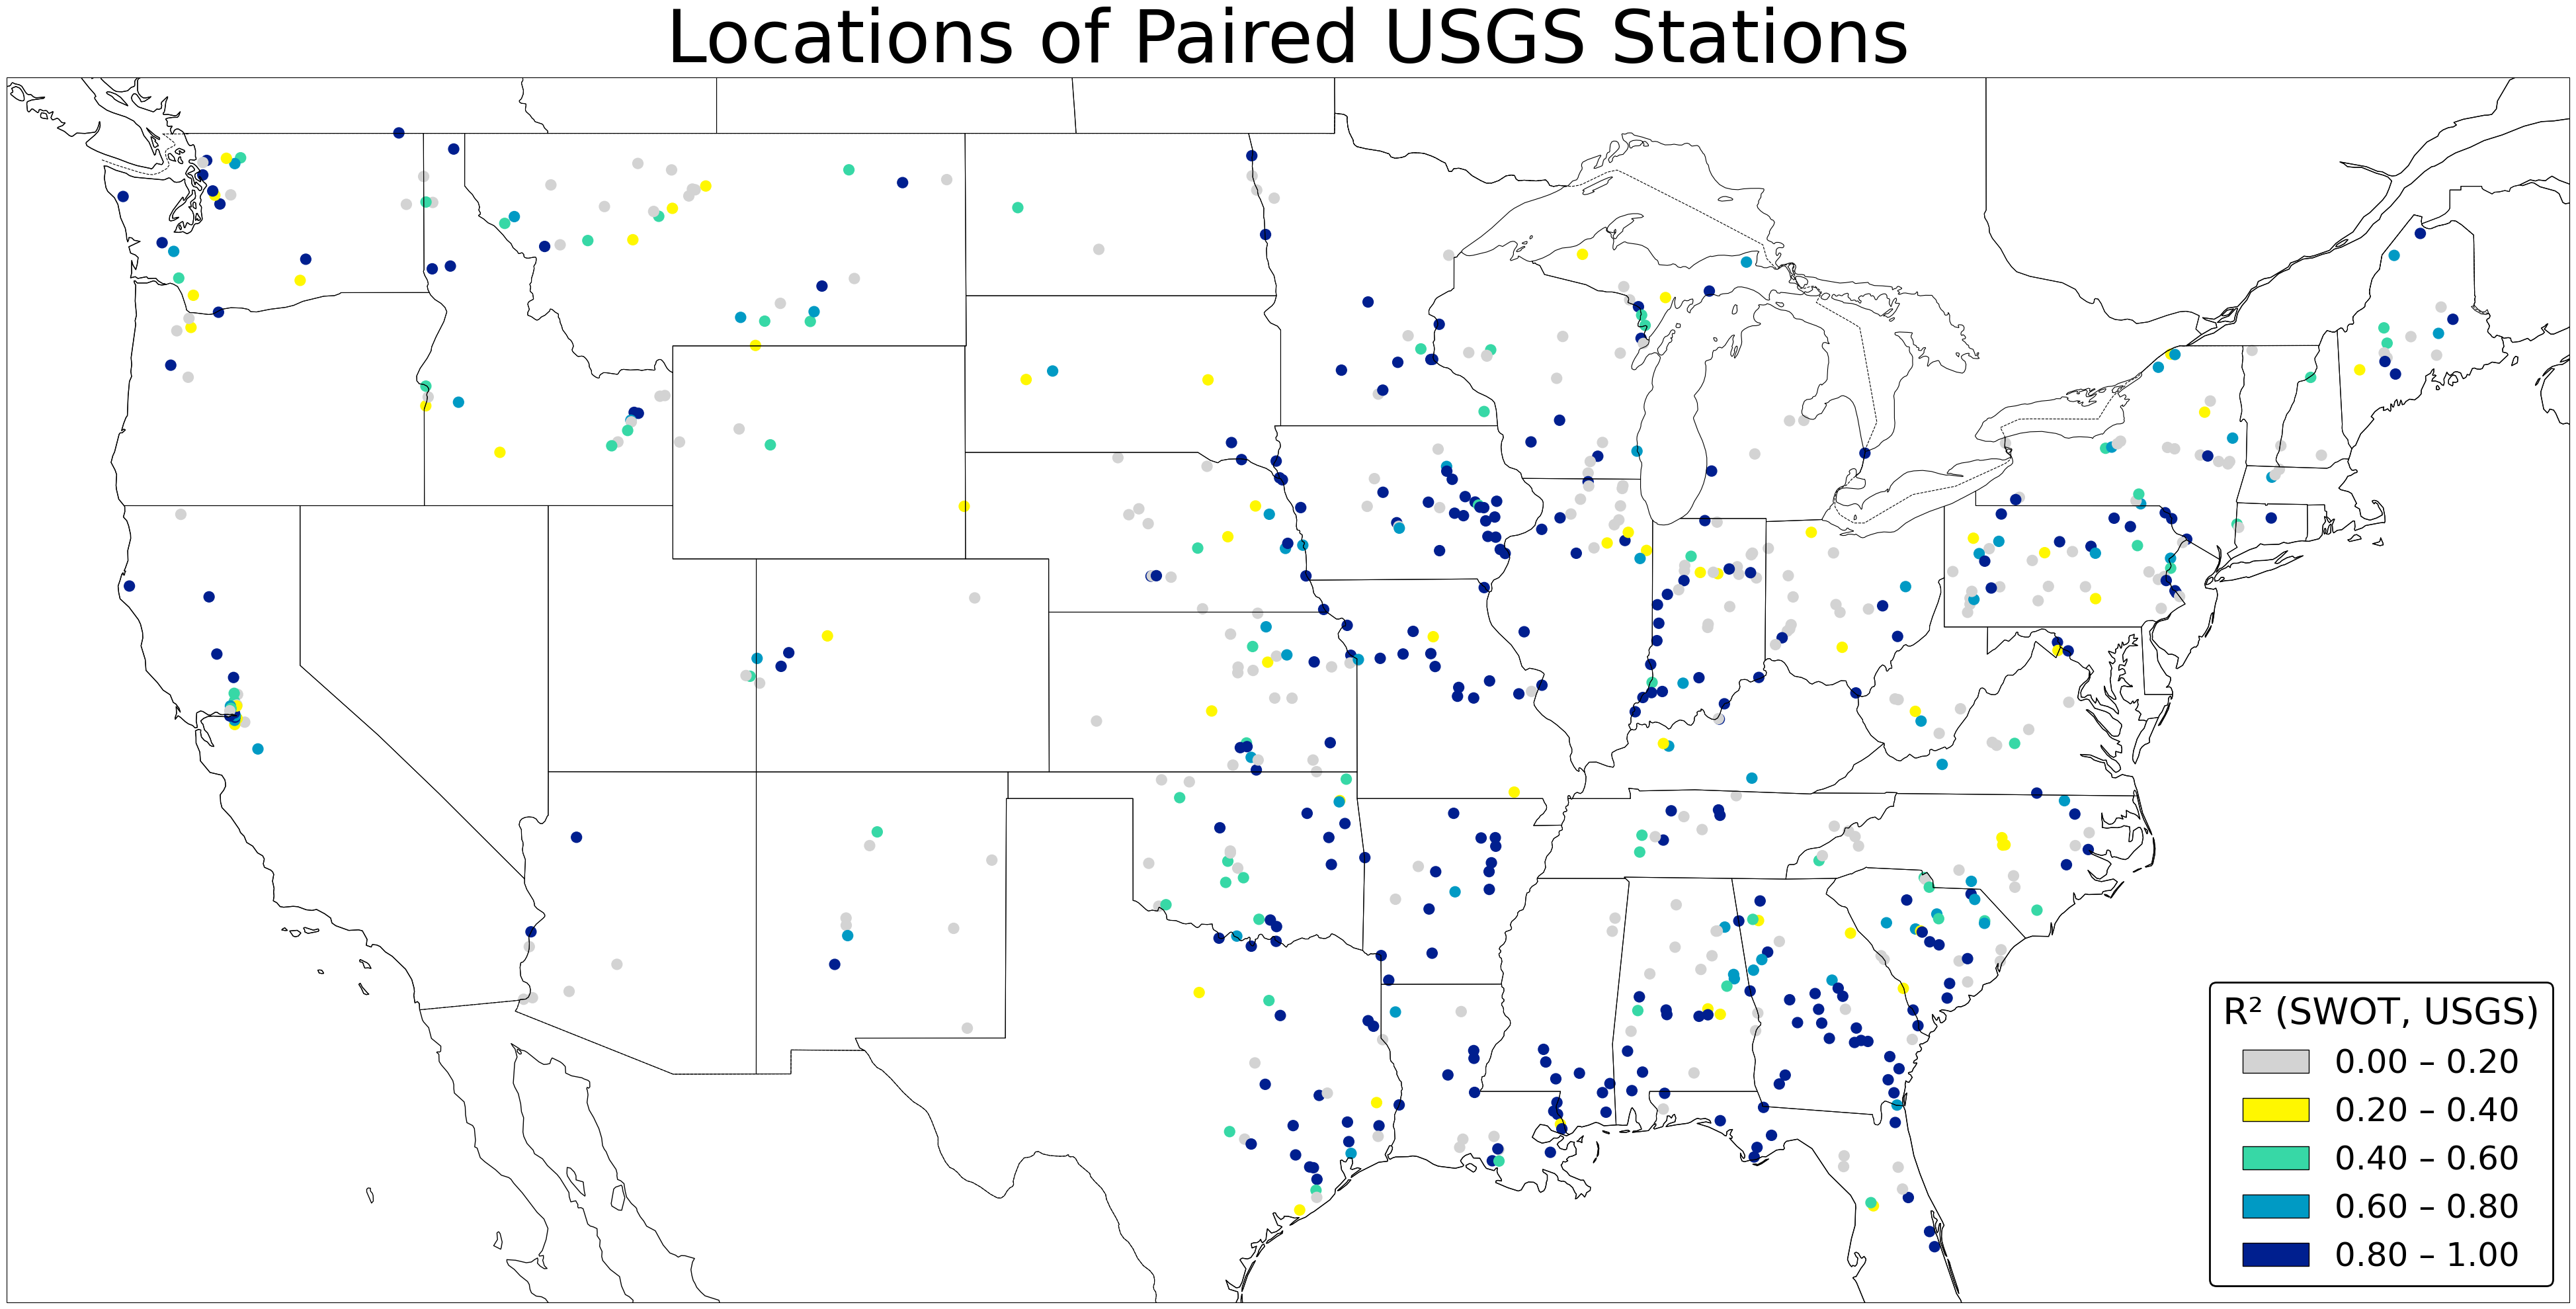

In [415]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import numpy as np
from matplotlib.colors import ListedColormap
from matplotlib.ticker import MultipleLocator, FixedFormatter
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.stats import norm
# Read shapefile

gdf=station_geometry

gdf = gdf.merge(experimental, left_on='monitoring_location_id', right_on='monitoring_location_id', how='inner')

bins=[0,0.2,0.4,0.6,0.8,1.0]
# Assign each polygon to a bin
cmap = ListedColormap([
    "lightgray",
    "#fff700",   # more saturated yellow
    "#37d8a6",   # more saturated turquoise-green
    "#009ac4",   # more saturated cyan-blue
    "#001f8f",    # deeper blue
])
norm = BoundaryNorm(bins, cmap.N)

gdf = gdf.set_crs("EPSG:4326")

gdf = gdf[gdf['monitoring_location_id'].isin(wse_error_filtered['monitoring_location_id'].unique())]
# Plot
fig, ax = plt.subplots(figsize=(50, 40),
                       subplot_kw={'projection': ccrs.PlateCarree()})

gdf.plot(ax=ax,
        column = 'R2',
        cmap=cmap,
        norm=BoundaryNorm(bins, ncolors=cmap.N),
        legend=False,
        markersize=130)

# Build legend entries
labels = []
for i in range(len(bins)-1):
    labels.append(f"{bins[i]:.2f} – {bins[i+1]:.2f}")

legend_handles = [
    Patch(facecolor=cmap(i), edgecolor='black', label=labels[i])
    for i in range(len(labels))
]

# Add legend (place it outside the map)
legend = ax.legend(
    handles=legend_handles,
    title=r"R² (SWOT, USGS)",
    title_fontsize=40,
    fontsize=36,
    loc='lower right',
    frameon=True,
    framealpha=1.0,
    borderpad=.4
)

# Make legend box border bold
legend.get_frame().set_linewidth(2)
legend.get_frame().set_edgecolor("black")
# Add features
ax.coastlines()
ax.add_feature(cfeature.STATES, edgecolor="black", linewidth=.8)
ax.add_feature(cfeature.BORDERS, linestyle='--', edgecolor="black", linewidth=0.8)
ax.set_facecolor('white')
plt.title("Locations of Paired USGS Stations", fontsize=80)
plt.show()

/opt/anaconda3/envs/swot/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/anaconda3/envs/swot/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


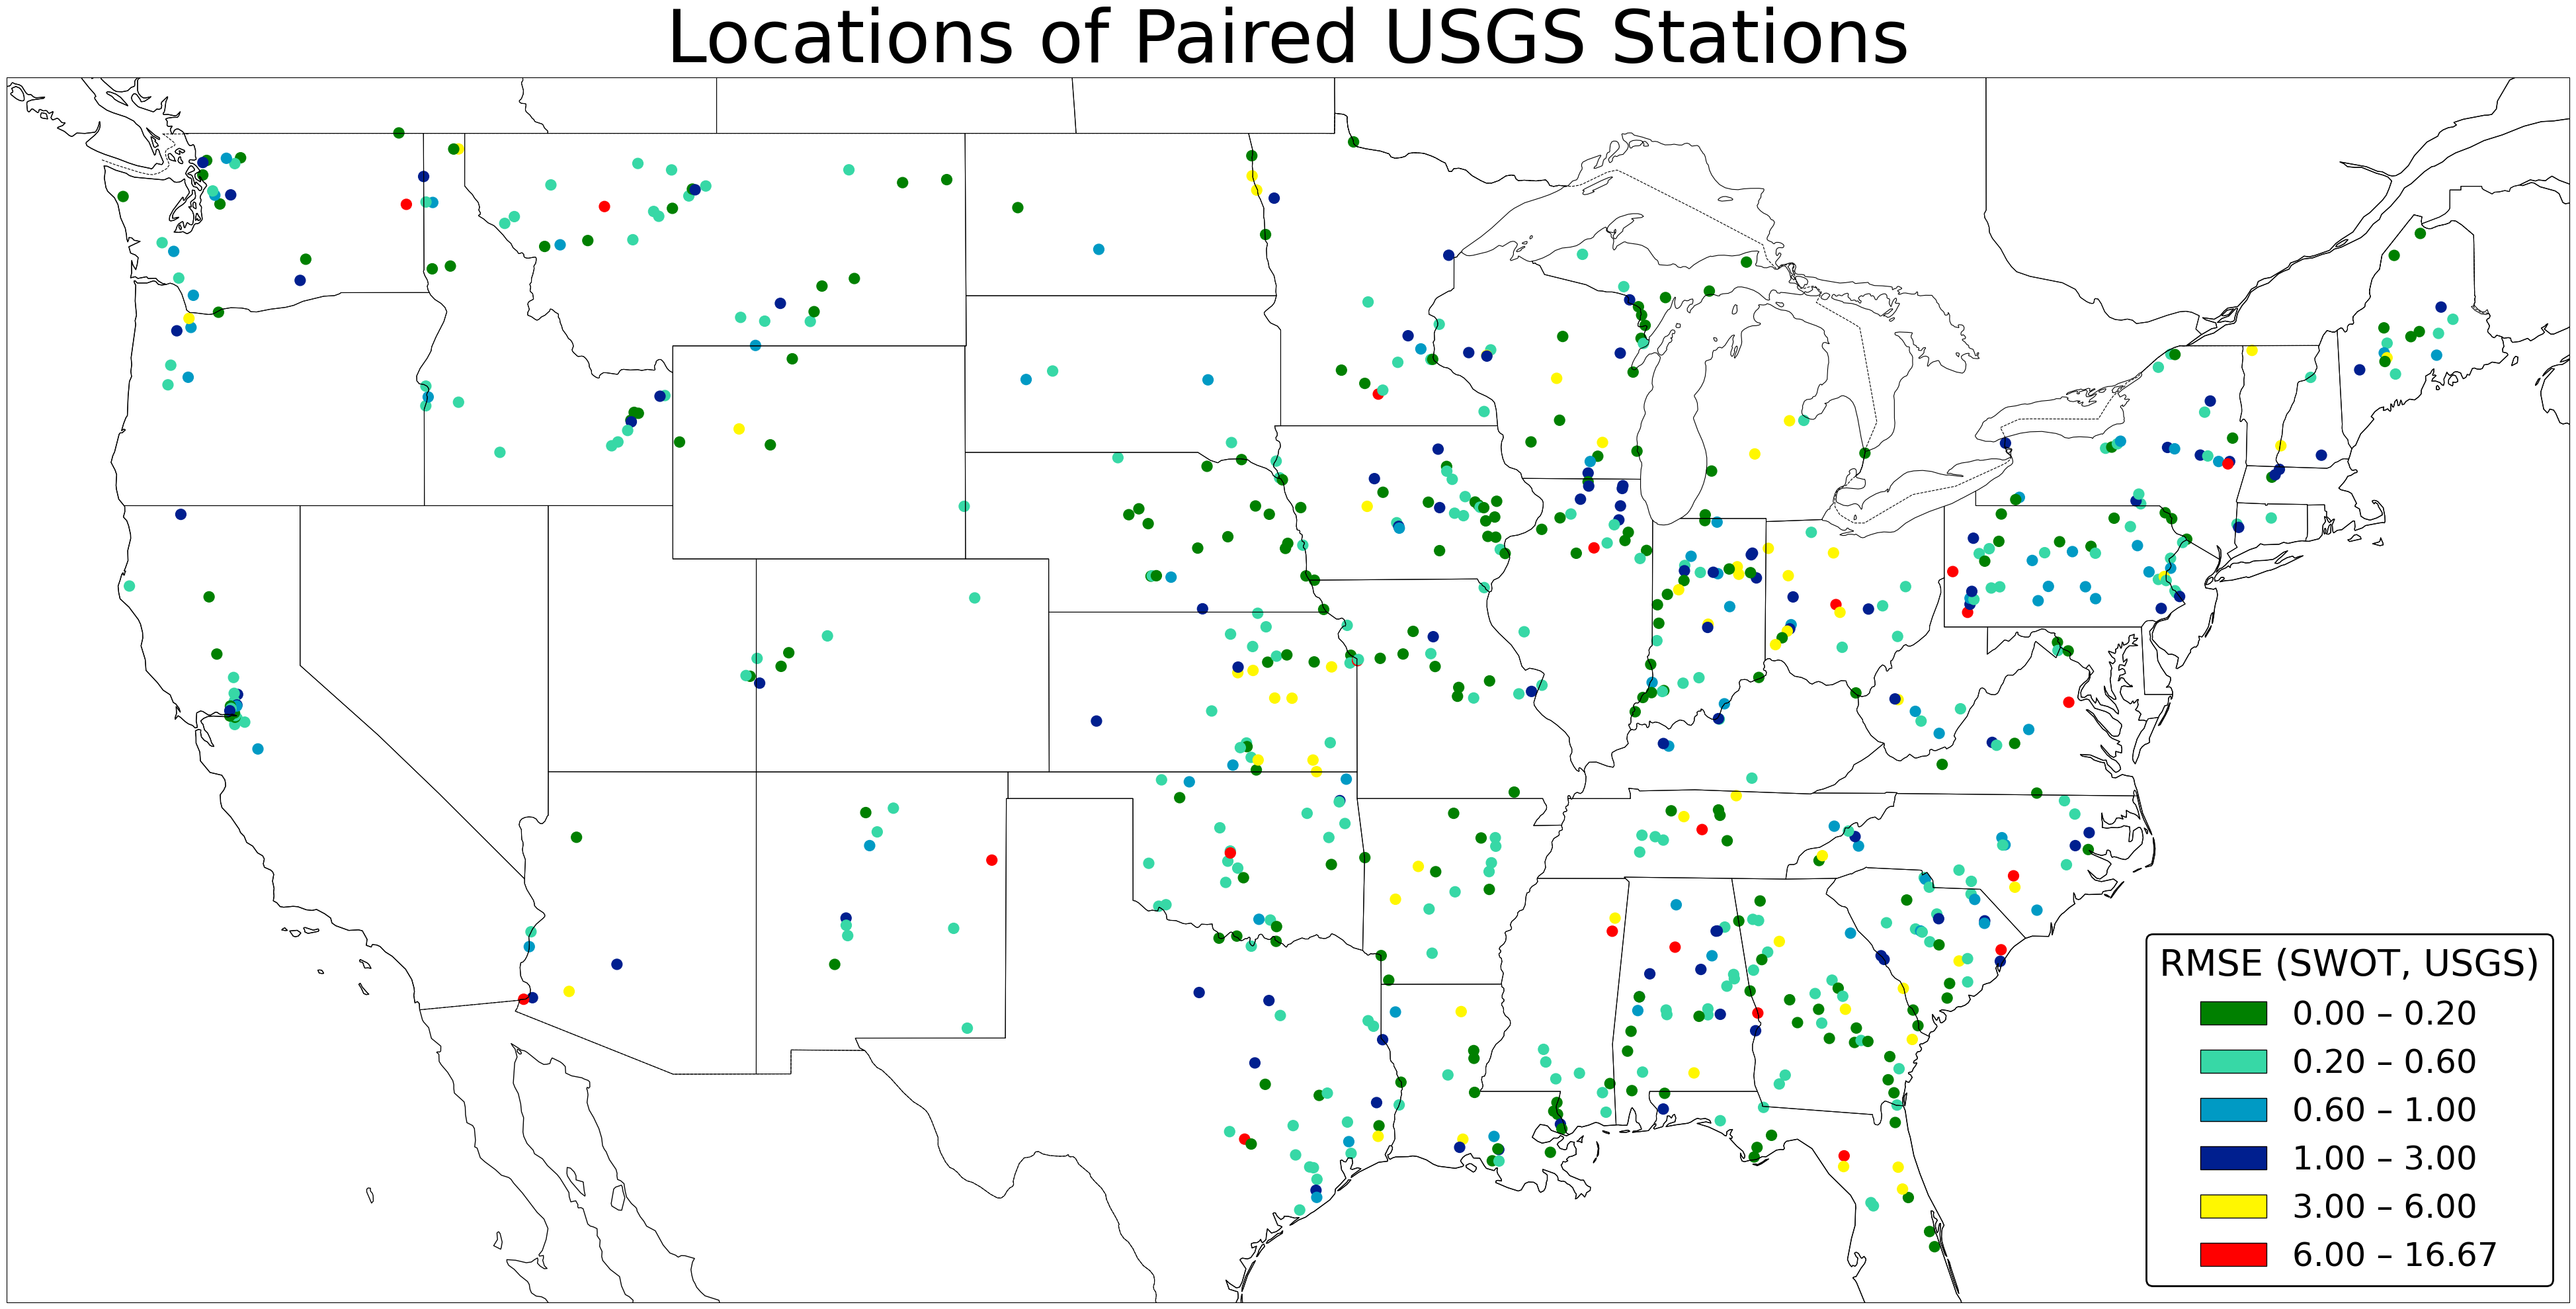

In [428]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import numpy as np
from matplotlib.colors import ListedColormap
from matplotlib.ticker import MultipleLocator, FixedFormatter
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.stats import norm
# Read shapefile

gdf=station_geometry

gdf = gdf.merge(experimental, left_on='monitoring_location_id', right_on='monitoring_location_id', how='inner')

bins=[0,0.2,0.6,1,3,6,np.max(experimental['RMSE'])]
# Assign each polygon to a bin
cmap = ListedColormap([
    'green',
    # "lightgray",
    "#37d8a6",   # more saturated turquoise-green
    "#009ac4",   # more saturated cyan-blue
    "#001f8f",    # deeper blue
    "#fff700",   # more saturated yellow
    
    
    
    
    
    "red"
])
norm = BoundaryNorm(bins, cmap.N)

gdf = gdf.set_crs("EPSG:4326")

gdf = gdf[gdf['monitoring_location_id'].isin(wse_error_filtered['monitoring_location_id'].unique())]
# Plot
fig, ax = plt.subplots(figsize=(50, 40),
                       subplot_kw={'projection': ccrs.PlateCarree()})

gdf.plot(ax=ax,
        column = 'RMSE',
        cmap=cmap,
        norm=BoundaryNorm(bins, ncolors=cmap.N),
        legend=False,
        markersize=130)

# Build legend entries
labels = []
for i in range(len(bins)-1):
    labels.append(f"{bins[i]:.2f} – {bins[i+1]:.2f}")

legend_handles = [
    Patch(facecolor=cmap(i), edgecolor='black', label=labels[i])
    for i in range(len(labels))
]

# Add legend (place it outside the map)
legend = ax.legend(
    handles=legend_handles,
    title=r"RMSE (SWOT, USGS)",
    title_fontsize=40,
    fontsize=36,
    loc='lower right',
    frameon=True,
    framealpha=1.0,
    borderpad=.4
)

# Make legend box border bold
legend.get_frame().set_linewidth(2)
legend.get_frame().set_edgecolor("black")
# Add features
ax.coastlines()
ax.add_feature(cfeature.STATES, edgecolor="black", linewidth=.8)
ax.add_feature(cfeature.BORDERS, linestyle='--', edgecolor="black", linewidth=0.8)
ax.set_facecolor('white')
plt.title("Locations of Paired USGS Stations", fontsize=80)
plt.show()